Fetching house price data...


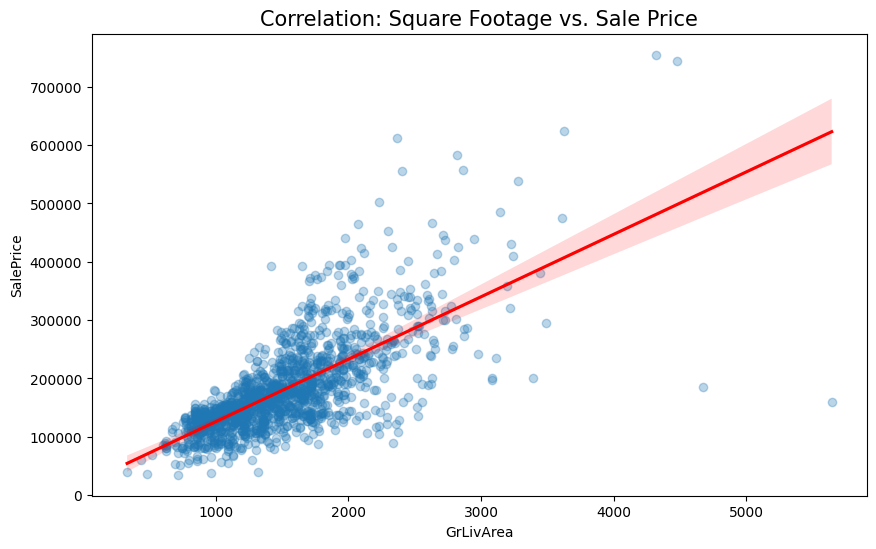

--- Model Performance ---
Mean Absolute Error: $28,107.98
R-Squared Score: 0.75


/tmp/ipykernel_21347/3977039065.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')


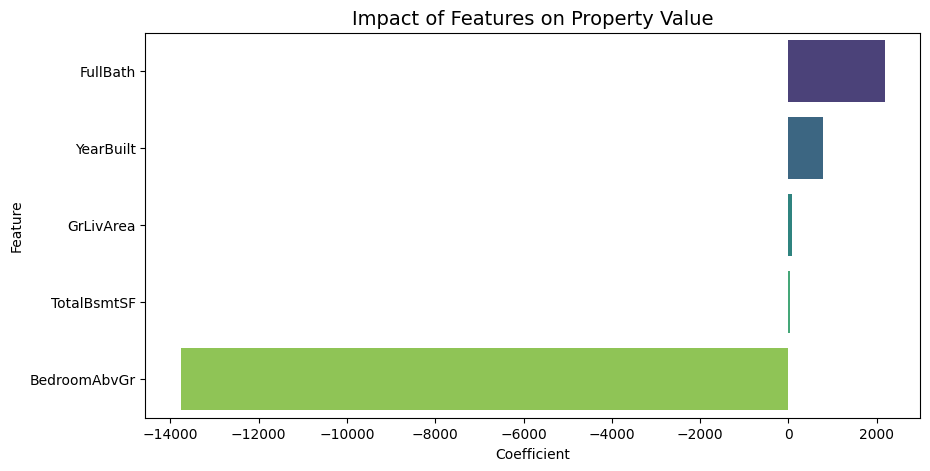

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.datasets import fetch_openml

# 1. Load Dataset (Ames Housing)
# This is a robust dataset for showing regression skills
print("Fetching house price data...")
housing = fetch_openml(name="house_prices", as_frame=True, parser='auto')
df = housing.frame

# 2. Focused Feature Selection
# Choosing features a Financial Specialist would care about
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'TotalBsmtSF', 'YearBuilt']
target = 'SalePrice'

# Simple cleaning: Drop rows with missing values in our selected features
data = df[features + [target]].dropna()

# 3. Exploratory Data Analysis (EDA)
plt.figure(figsize=(10, 6))
sns.regplot(x='GrLivArea', y='SalePrice', data=data,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation: Square Footage vs. Sale Price', fontsize=15)
plt.show()

# 4. Modeling (Linear Regression)
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 5. Evaluation
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- Model Performance ---")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-Squared Score: {r2:.2f}")

# 6. Feature Importance Visualization
importance = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
importance = importance.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='viridis')
plt.title('Impact of Features on Property Value', fontsize=14)
plt.show()